#  NMT Seq2Seq (LSTM) Model: English to Bengali/Hindi

This notebook implements a full sequence-to-sequence (Seq2Seq) pipeline for neural machine translation (NMT) from scratch in PyTorch.

**Key Features:**
* **Architecture:** Encoder-Decoder Model using **LSTMs** (Long Short-Term Memory).
* **Training:** Uses **Teacher Forcing** to stabilize and speed up training.
* **Data:** Loads data from `train_data1.json`, validates on `val_data1.json`, and predicts on `test_data1.json`.
* **Reusability:** The notebook is parameterized to run for one language pair at a time (e.g., English-Bengali). You can easily re-run it for English-Hindi by changing a single variable (`LANG_PAIR_KEY`).

## Step 1: Imports and Setup

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset

import json
import numpy as np
import pandas as pd
import re
import string
import nltk
import matplotlib.pyplot as plt
from tqdm import tqdm
import random
import time
import math

In [2]:
from google.colab import drive
drive.mount('/content/drive')

MessageError: Error: credential propagation was unsuccessful

In [16]:
# Download the NLTK tokenizer models
# The toy model used 'punkt_tab', we'll use the standard 'punkt'
nltk.download('punkt')
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

In [3]:
# -- Constants and Configuration --

# 1. CHOOSE YOUR LANGUAGE PAIR KEY (from the JSON file)
# Run once with "English-Bengali", then re-run with "English-Hindi"
#LANG_PAIR_KEY = "English-Bengali"
LANG_PAIR_KEY = "English-Hindi"

# 2. SET YOUR FILE PATHS (Update these to your Google Drive paths)
# Assuming data is in a folder named 'NMT_data' in your 'My Drive'
BASE_PATH = "/content/drive/My Drive/NMT_data/"
TRAIN_FILE_PATH = "/content/train_data1.json" # Using local path from toy model
VAL_FILE_PATH = "/content/val_data1.json"     # You will need to upload this
TEST_FILE_PATH = "/content/val_data1.json" # Using local path from toy model

# 3. DEFINE SPECIAL TOKENS
PAD_token = 0
SOS_token = 1
EOS_token = 2

# 4. SET DEVICE
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# 5. SET OUTPUT FILENAME (change this for the second run)
if LANG_PAIR_KEY == "English-Bengali":
    OUTPUT_CSV_NAME = "answersB.csv"
    BEST_MODEL_NAME = "best-model-bengali.pt"
else:
    OUTPUT_CSV_NAME = "answersH.csv"
    BEST_MODEL_NAME = "best-model-hindi.pt"

Using device: cuda


## Step 2: Data Loading

We'll load the train, validation, and test JSON files.

In [4]:
# Load Train data
try:
    with open(TRAIN_FILE_PATH, 'r') as file:
        train_data = json.load(file)
    print(f"Successfully loaded {TRAIN_FILE_PATH}")
except FileNotFoundError:
    print(f"ERROR: {TRAIN_FILE_PATH} not found. Please upload it or check the path.")

Successfully loaded /content/train_data1.json


In [5]:
# Load Validation data
# Note: The toy model did not use the validation set for validation loss.
# We WILL use it to monitor overfitting.
try:
    with open(VAL_FILE_PATH, 'r') as file:
        val_data = json.load(file)
    print(f"Successfully loaded {VAL_FILE_PATH}")
except FileNotFoundError:
    print(f"ERROR: {VAL_FILE_PATH} not found. Please upload it or check the path.")
    val_data = None # Set to None if not found so the code can proceed

Successfully loaded /content/val_data1.json


In [6]:
# Load Test data
try:
    with open(TEST_FILE_PATH, 'r') as file:
        test_data = json.load(file)
    print(f"Successfully loaded {TEST_FILE_PATH}")
except FileNotFoundError:
    print(f"ERROR: {TEST_FILE_PATH} not found. Please upload it or check the path.")

Successfully loaded /content/val_data1.json


## Step 3: Data Extraction and Preprocessing

First, we'll write a clean function to extract the sentences for our chosen language pair. Then, we'll write preprocessing and tokenization functions.

In [7]:
def extract_data(data, lang_pair_key, split):
    """Extracts source sentences, target sentences, and IDs from the loaded JSON data."""
    source_sentences = []
    target_sentences = []
    entry_ids = []

    print(f"Extracting data for {lang_pair_key} - {split}...")

    # Check if the language pair and split exist
    if lang_pair_key not in data:
        print(f"Error: Language pair '{lang_pair_key}' not in data.")
        return [], [], []
    if split not in data[lang_pair_key]:
        print(f"Error: Split '{split}' not in data for {lang_pair_key}.")
        return [], [], []

    data_entries = data[lang_pair_key][split]

    for entry_id, entry_data in data_entries.items():
        entry_ids.append(entry_id)
        source_sentences.append(entry_data["source"])

        # Test set does not have a 'target' key
        if "target" in entry_data:
            target_sentences.append(entry_data["target"])

    if not target_sentences and split != "Test":
        print(f"Warning: No target sentences found for {split} split.")
        return source_sentences, None, entry_ids

    if split == "Test":
        return source_sentences, None, entry_ids

    return source_sentences, target_sentences, entry_ids

In [8]:
# Extract data for all splits
source_sentences_train, target_sentences_train, id_train = extract_data(train_data, LANG_PAIR_KEY, "Train")

if val_data:
    source_sentences_val, target_sentences_val, id_val = extract_data(val_data, LANG_PAIR_KEY, "Validation")
else:
    print("No validation data loaded. Skipping validation set extraction.")
    source_sentences_val, target_sentences_val, id_val = [], [], []

source_sentences_test, _, id_test = extract_data(test_data, LANG_PAIR_KEY, "Test")

print("\n--- Data Loading Summary ---")
print(f"Train examples: {len(source_sentences_train)}")
print(f"Valid examples: {len(source_sentences_val)}")
print(f"Test examples:  {len(source_sentences_test)}")

print("\nExample Train Pair:")
print(f"  EN: {source_sentences_train[0]}")
print(f"  TGT: {target_sentences_train[0]}")

Extracting data for English-Hindi - Train...
Extracting data for English-Hindi - Validation...
Extracting data for English-Hindi - Test...
Error: Split 'Test' not in data for English-Hindi.

--- Data Loading Summary ---
Train examples: 80797
Valid examples: 11543
Test examples:  0

Example Train Pair:
  EN: cancel everything on my calendar
  TGT: मेरे कैलेंडर पर सब कुछ रद्द करें


In [9]:
def preprocess_sentence(sentence, lang='en'):
    """Cleans, normalizes, and tokenizes a single sentence."""

    # 1. Lowercase
    sentence = sentence.lower()

    # 2. Remove punctuation and numbers
    # Keep spaces and basic letters (English or otherwise)
    sentence = re.sub(r'[' + string.punctuation + ']', '', sentence)
    sentence = re.sub(r'[0-9]+', '', sentence)

    # 3. (For Target Only) Remove any stray English chars
    # This was done in the toy model for the target language
    if lang == 'tgt':
        sentence = re.sub(r'[a-zA-Z]', '', sentence)

    # 4. Remove extra whitespace
    sentence = re.sub(r'\s+', ' ', sentence).strip()

    # 5. Tokenize
    return nltk.word_tokenize(sentence)

In [17]:
# Preprocess all sentences
print("Preprocessing (tokenizing) sentences...")
en_train_tokens = [preprocess_sentence(s, lang='en') for s in tqdm(source_sentences_train)]
tgt_train_tokens = [preprocess_sentence(s, lang='tgt') for s in tqdm(target_sentences_train)]

en_val_tokens = [preprocess_sentence(s, lang='en') for s in tqdm(source_sentences_val)]
# Only process target validation tokens if they exist
if target_sentences_val:
    tgt_val_tokens = [preprocess_sentence(s, lang='tgt') for s in tqdm(target_sentences_val)]
else:
    tgt_val_tokens = None

en_test_tokens = [preprocess_sentence(s, lang='en') for s in tqdm(source_sentences_test)]

print("\nExample processed pair:")
print(f"  EN: {en_train_tokens[0]}")
print(f"  TGT: {tgt_train_tokens[0]}")

Preprocessing (tokenizing) sentences...


100%|██████████| 11543/11543 [00:01<00:00, 8426.09it/s]
0it [00:00, ?it/s]


Example processed pair:
  EN: ['cancel', 'everything', 'on', 'my', 'calendar']
  TGT: ['मेरे', 'कैलेंडर', 'पर', 'सब', 'कुछ', 'रद्द', 'करें']


## Step 4: Vocabulary Building

We'll create a `Vocab` class to map words to indices. We **only** build the vocabulary from the **training set** to prevent data leakage.

In [18]:
class Vocab:
    def __init__(self):
        self.word2index = {"<PAD>": PAD_token, "<SOS>": SOS_token, "<EOS>": EOS_token}
        self.index2word = {PAD_token: "<PAD>", SOS_token: "<SOS>", EOS_token: "<EOS>"}
        self.n_words = 3  # Count PAD, SOS, EOS

    def add_sentence(self, sentence_tokens):
        for word in sentence_tokens:
            self.add_word(word)

    def add_word(self, word):
        if word not in self.word2index:
            self.word2index[word] = self.n_words
            self.index2word[self.n_words] = word
            self.n_words += 1


In [19]:
# Build vocabularies
en_vocab = Vocab()
tgt_vocab = Vocab()

print("Building English vocab from training data...")
for sent_tokens in tqdm(en_train_tokens):
    en_vocab.add_sentence(sent_tokens)

print("Building Target vocab from training data...")
for sent_tokens in tqdm(tgt_train_tokens):
    tgt_vocab.add_sentence(sent_tokens)

print("\n--- Vocab Summary ---")
print(f"English (Source) Vocab Size: {en_vocab.n_words}")
print(f"Target Vocab Size: {tgt_vocab.n_words}")

Building English vocab from training data...


100%|██████████| 80797/80797 [00:00<00:00, 356964.20it/s]


Building Target vocab from training data...


100%|██████████| 80797/80797 [00:00<00:00, 281316.82it/s]


--- Vocab Summary ---
English (Source) Vocab Size: 57278
Target Vocab Size: 72586


## Step 5: Encoding and Padding

Now we convert all our tokenized sentences into numerical sequences (indices) and pad/truncate them to a fixed `MAX_LENGTH`.

In [20]:
# Set a maximum length for sequences
# The toy model used 20. Let's try 25 for a bit more room.
MAX_LENGTH = 25

def encode_and_pad(sentence_tokens, vocab, max_length):
    """Converts tokenized sentence to a padded/truncated list of indices."""

    # 1. Start with SOS token
    encoded = [vocab.word2index["<SOS>"]]

    # 2. Add indices for words, skipping unknown words
    for token in sentence_tokens:
        if token in vocab.word2index:
            encoded.append(vocab.word2index[token])

    # 3. Add EOS token
    encoded.append(vocab.word2index["<EOS>"])

    # 4. Truncate if necessary (before padding)
    if len(encoded) > max_length:
        encoded = encoded[:max_length - 1] + [vocab.word2index["<EOS>"]]

    # 5. Pad with PAD_token
    n_pads = max_length - len(encoded)
    encoded.extend([vocab.word2index["<PAD>"]] * n_pads)

    return encoded

In [21]:
print("Encoding and padding all datasets...")

en_train_encoded = [encode_and_pad(s, en_vocab, MAX_LENGTH) for s in tqdm(en_train_tokens)]
tgt_train_encoded = [encode_and_pad(s, tgt_vocab, MAX_LENGTH) for s in tqdm(tgt_train_tokens)]

en_val_encoded = [encode_and_pad(s, en_vocab, MAX_LENGTH) for s in tqdm(en_val_tokens)]
if tgt_val_tokens:
    tgt_val_encoded = [encode_and_pad(s, tgt_vocab, MAX_LENGTH) for s in tqdm(tgt_val_tokens)]
else:
    tgt_val_encoded = None

#en_test_encoded = [encode_and_pad(s, en_vocab, MAX_LENGTH) for s in tqdm(en_test_tokens)]

print("\nExample encoded pair:")
print(f"  EN (tokens): {en_train_tokens[0]}")
print(f"  EN (encoded): {en_train_encoded[0]}")
print(f"  TGT (tokens): {tgt_train_tokens[0]}")
print(f"  TGT (encoded): {tgt_train_encoded[0]}")

Encoding and padding all datasets...


100%|██████████| 11543/11543 [00:00<00:00, 204737.33it/s]


Example encoded pair:
  EN (tokens): ['cancel', 'everything', 'on', 'my', 'calendar']
  EN (encoded): [1, 3, 4, 5, 6, 7, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
  TGT (tokens): ['मेरे', 'कैलेंडर', 'पर', 'सब', 'कुछ', 'रद्द', 'करें']
  TGT (encoded): [1, 3, 4, 5, 6, 7, 8, 9, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]


## Step 6: Create PyTorch DataLoaders

We'll convert our encoded lists into PyTorch Tensors and use `DataLoader` to create batches.

In [22]:
BATCH_SIZE = 64

# Convert to Tensors
en_train_tensor = torch.LongTensor(en_train_encoded).to(device)
tgt_train_tensor = torch.LongTensor(tgt_train_encoded).to(device)
en_val_tensor = torch.LongTensor(en_val_encoded).to(device)
#en_test_tensor = torch.LongTensor(en_test_encoded).to(device)

# Create TensorDatasets
train_ds = TensorDataset(en_train_tensor, tgt_train_tensor)
#test_ds = TensorDataset(en_test_tensor) # For test set predictions
val_pred_ds = TensorDataset(en_val_tensor) # For validation set predictions

# Create DataLoaders
train_loader = DataLoader(train_ds, shuffle=True, batch_size=BATCH_SIZE)
#test_loader = DataLoader(test_ds, shuffle=False, batch_size=1) # batch_size=1 for inference
val_pred_loader = DataLoader(val_pred_ds, shuffle=False, batch_size=1) # batch_size=1 for inference
print(f"Train DataLoader: {len(train_loader)} batches of size {BATCH_SIZE}")
#print(f"Test Inference Loader:  {len(test_loader)} batches of size 1")
print(f"Valid Inference Loader: {len(val_pred_loader)} batches of size 1")

# We will not have a validation loss loader, so we set it to None
val_loader = None
if tgt_val_encoded:
    tgt_val_tensor = torch.LongTensor(tgt_val_encoded).to(device)
    val_ds = TensorDataset(en_val_tensor, tgt_val_tensor)
    val_loader = DataLoader(val_ds, shuffle=False, batch_size=BATCH_SIZE)
    print(f"Valid Loss Loader: {len(val_loader)} batches of size {BATCH_SIZE}")
else:
    print("No validation targets found. Validation loss will not be calculated.")

Train DataLoader: 1263 batches of size 64
Valid Inference Loader: 11543 batches of size 1
No validation targets found. Validation loss will not be calculated.


## Step 7: Model Architecture (LSTM Seq2Seq)

Here we define the three main components:
1.  `EncoderLSTM`: Reads the English sentence and outputs a `context` (hidden and cell states).
2.  `DecoderLSTM`: Takes the `context` and generates the target sentence token by token.
3.  `Seq2Seq`: A wrapper that combines the encoder and decoder, and implements the Teacher Forcing logic.

In [23]:
class EncoderLSTM(nn.Module):
    def __init__(self, input_size, embed_size, hidden_size, num_layers, dropout_p):
        super(EncoderLSTM, self).__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers

        self.embedding = nn.Embedding(input_size, embed_size, padding_idx=PAD_token)
        self.dropout = nn.Dropout(dropout_p)
        self.lstm = nn.LSTM(
            embed_size,
            hidden_size,
            num_layers,
            dropout=dropout_p,
            batch_first=True # This is important! Input shape is (batch_size, seq_len)
        )

    def forward(self, x):
        # x shape: (batch_size, seq_len)
        embedded = self.dropout(self.embedding(x))
        # embedded shape: (batch_size, seq_len, embed_size)

        # LSTM returns outputs, (hidden_state, cell_state)
        # We don't need the 'outputs' (hidden states of all timesteps) for a basic Seq2Seq
        _, (hidden, cell) = self.lstm(embedded)

        # hidden shape: (num_layers, batch_size, hidden_size)
        # cell shape: (num_layers, batch_size, hidden_size)
        return hidden, cell

In [24]:
class DecoderLSTM(nn.Module):
    def __init__(self, output_size, embed_size, hidden_size, num_layers, dropout_p):
        super(DecoderLSTM, self).__init__()
        self.output_size = output_size
        self.hidden_size = hidden_size
        self.num_layers = num_layers

        self.embedding = nn.Embedding(output_size, embed_size, padding_idx=PAD_token)
        self.dropout = nn.Dropout(dropout_p)
        self.lstm = nn.LSTM(
            embed_size,
            hidden_size,
            num_layers,
            dropout=dropout_p,
            batch_first=True
        )
        # Fully-connected layer to map from hidden_size to vocab_size
        self.fc_out = nn.Linear(hidden_size, output_size)

    def forward(self, x, hidden, cell):
        # x shape: (batch_size) - just the current token
        # We need to add a sequence length dimension of 1
        x = x.unsqueeze(1)
        # x shape: (batch_size, 1)

        embedded = self.dropout(self.embedding(x))
        # embedded shape: (batch_size, 1, embed_size)

        # Pass previous hidden/cell states into the LSTM
        output, (hidden, cell) = self.lstm(embedded, (hidden, cell))
        # output shape: (batch_size, 1, hidden_size)

        # Get the logits (raw scores) for the vocabulary
        # We squeeze(1) to remove the sequence dimension
        predictions = self.fc_out(output.squeeze(1))
        # predictions shape: (batch_size, output_size)

        return predictions, hidden, cell

In [25]:
class Seq2Seq(nn.Module):
    def __init__(self, encoder, decoder, device):
        super(Seq2Seq, self).__init__()
        self.encoder = encoder
        self.decoder = decoder
        self.device = device

        # Ensure encoder and decoder hidden sizes match
        assert encoder.hidden_size == decoder.hidden_size, \
            "Encoder and Decoder hidden sizes must match!"
        assert encoder.num_layers == decoder.num_layers, \
            "Encoder and Decoder number of layers must match!"

    def forward(self, src, tgt, teacher_forcing_ratio=0.5):
        # src shape: (batch_size, src_len)
        # tgt shape: (batch_size, tgt_len)

        batch_size = src.shape[0]
        tgt_len = tgt.shape[1]
        tgt_vocab_size = self.decoder.output_size

        # Tensor to store all decoder outputs
        outputs = torch.zeros(batch_size, tgt_len, tgt_vocab_size).to(self.device)

        # 1. Pass the source sentence through the encoder
        # The final hidden and cell states are our 'context vector'
        hidden, cell = self.encoder(src)

        # 2. Decoder loop
        # The first input to the decoder is the <SOS> token
        # We get this from the target data (it's always the first token)
        x = tgt[:, 0]

        # We loop from 1 because we already have the 0-th token (<SOS>)
        # The model's first prediction will be for the 1st token
        for t in range(1, tgt_len):
            # Pass the input token and context states to the decoder
            output, hidden, cell = self.decoder(x, hidden, cell)

            # Store this prediction
            outputs[:, t] = output

            # Decide whether to use 'teacher forcing'
            use_teacher_forcing = random.random() < teacher_forcing_ratio

            # Get the token with the highest score
            top1 = output.argmax(1)

            # Set the next input to the decoder
            # If teacher forcing, use the real token from the target data
            # Otherwise, use the decoder's own prediction
            x = tgt[:, t] if use_teacher_forcing else top1

        return outputs

## Step 8: Training the Model

First, we set our hyperparameters and instantiate the model, optimizer, and loss function. Then, we'll write the `train` and `evaluate` functions and start the training loop.

In [26]:
# -- Hyperparameters --
INPUT_DIM = en_vocab.n_words
OUTPUT_DIM = tgt_vocab.n_words
EMBED_SIZE = 256        # Size of token embeddings
HIDDEN_SIZE = 512       # Size of the LSTM hidden state (and cell state)
NUM_LAYERS = 2          # Number of layers in the LSTM (a 2-layer LSTM is good)
DROPOUT = 0.5           # Dropout probability
LEARNING_RATE = 0.001   # Adam optimizer learning rate
NUM_EPOCHS = 10         # Start with 10 epochs
CLIP = 1.0              # Gradient clipping value
TEACHER_FORCING_RATIO = 0.5 # 50% chance of using teacher forcing

# -- Model Instantiation --
encoder = EncoderLSTM(INPUT_DIM, EMBED_SIZE, HIDDEN_SIZE, NUM_LAYERS, DROPOUT).to(device)
decoder = DecoderLSTM(OUTPUT_DIM, EMBED_SIZE, HIDDEN_SIZE, NUM_LAYERS, DROPOUT).to(device)

model = Seq2Seq(encoder, decoder, device).to(device)

# -- Optimizer and Loss --
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

# We use CrossEntropyLoss, which handles the Softmax for us.
# We tell it to ignore the PAD_token so we don't calculate loss on padding.
criterion = nn.CrossEntropyLoss(ignore_index=PAD_token)

print("--- Model Summary ---")
print(f"Source (EN) Vocab: {INPUT_DIM}")
print(f"Target (TGT) Vocab: {OUTPUT_DIM}")
print(f"Embedding Size: {EMBED_SIZE}")
print(f"Hidden Size: {HIDDEN_SIZE}")
print(f"Num Layers: {NUM_LAYERS}")
print(model)

--- Model Summary ---
Source (EN) Vocab: 57278
Target (TGT) Vocab: 72586
Embedding Size: 256
Hidden Size: 512
Num Layers: 2
Seq2Seq(
  (encoder): EncoderLSTM(
    (embedding): Embedding(57278, 256, padding_idx=0)
    (dropout): Dropout(p=0.5, inplace=False)
    (lstm): LSTM(256, 512, num_layers=2, batch_first=True, dropout=0.5)
  )
  (decoder): DecoderLSTM(
    (embedding): Embedding(72586, 256, padding_idx=0)
    (dropout): Dropout(p=0.5, inplace=False)
    (lstm): LSTM(256, 512, num_layers=2, batch_first=True, dropout=0.5)
    (fc_out): Linear(in_features=512, out_features=72586, bias=True)
  )
)


In [27]:
def train_fn(model, loader, optimizer, criterion, clip, ratio):
    """Performs one epoch of training."""
    model.train() # Set model to training mode
    epoch_loss = 0

    for batch in tqdm(loader, desc="Training"):
        src, tgt = batch
        src, tgt = src.to(device), tgt.to(device)

        optimizer.zero_grad()

        # Forward pass
        output = model(src, tgt, teacher_forcing_ratio=ratio)
        # output shape: (batch_size, tgt_len, output_dim)

        # Reshape for loss function
        # We want (N, C), so (batch_size * (tgt_len-1), output_dim)
        # We skip the first token (<SOS>) from the output and target
        output_dim = output.shape[-1]
        output_for_loss = output[:, 1:].reshape(-1, output_dim)
        tgt_for_loss = tgt[:, 1:].reshape(-1)

        # Calculate loss
        loss = criterion(output_for_loss, tgt_for_loss)

        # Backward pass and optimization
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=clip)
        optimizer.step()

        epoch_loss += loss.item()

    return epoch_loss / len(loader)

In [28]:
def evaluate_fn(model, loader, criterion):
    """Performs one epoch of evaluation on the validation set."""
    model.eval() # Set model to evaluation mode
    epoch_loss = 0

    with torch.no_grad(): # No gradients needed
        for batch in tqdm(loader, desc="Validating"):
            src, tgt = batch
            src, tgt = src.to(device), tgt.to(device)

            # Forward pass (no teacher forcing for validation)
            output = model(src, tgt, teacher_forcing_ratio=0.0)

            # Reshape for loss
            output_dim = output.shape[-1]
            output_for_loss = output[:, 1:].reshape(-1, output_dim)
            tgt_for_loss = tgt[:, 1:].reshape(-1)

            loss = criterion(output_for_loss, tgt_for_loss)
            epoch_loss += loss.item()

    return epoch_loss / len(loader)

In [29]:
def epoch_time(start_time, end_time):
    """Helper function to format epoch time."""
    elapsed_time = end_time - start_time
    elapsed_mins = int(elapsed_time / 60)
    elapsed_secs = int(elapsed_time - (elapsed_mins * 60))
    return elapsed_mins, elapsed_secs

In [30]:
print("Starting Training...")

best_loss = float('inf')
train_losses = []
valid_losses = []

for epoch in range(NUM_EPOCHS):
    start_time = time.time()

    # Run training
    train_loss = train_fn(model, train_loader, optimizer, criterion, CLIP, TEACHER_FORCING_RATIO)
    train_losses.append(train_loss)

    current_loss = train_loss # Default loss to track

    # Run validation (if we have a val_loader)
    if val_loader:
        valid_loss = evaluate_fn(model, val_loader, criterion)
        valid_losses.append(valid_loss)
        current_loss = valid_loss # Track validation loss if available
    else:
        valid_loss = 0.0 # No validation loss to show

    end_time = time.time()
    epoch_mins, epoch_secs = epoch_time(start_time, end_time)

    # Save the best model
    if current_loss < best_loss:
        best_loss = current_loss
        torch.save(model.state_dict(), BEST_MODEL_NAME)

    print(f'\nEpoch: {epoch+1:02} | Time: {epoch_mins}m {epoch_secs}s')
    print(f'\tTrain Loss: {train_loss:.3f} | Train PPL: {math.exp(train_loss):7.3f}')
    if val_loader:
        print(f'\t Val. Loss: {valid_loss:.3f} |  Val. PPL: {math.exp(valid_loss):7.3f}')
    else:
        print(f'\t Val. Loss: N/A (No targets)')

print("Training finished.")
# If we didn't save a model based on validation, save the final epoch's model
if not val_loader:
    torch.save(model.state_dict(), BEST_MODEL_NAME)
    print(f"Saved final model as {BEST_MODEL_NAME}")

Starting Training...


Training: 100%|██████████| 1263/1263 [14:17<00:00,  1.47it/s]



Epoch: 01 | Time: 14m 17s
	Train Loss: 7.000 | Train PPL: 1097.042
	 Val. Loss: N/A (No targets)


Training: 100%|██████████| 1263/1263 [14:14<00:00,  1.48it/s]



Epoch: 02 | Time: 14m 14s
	Train Loss: 6.459 | Train PPL: 638.496
	 Val. Loss: N/A (No targets)


...


Epoch: 08 | Time: 14m 20s
	Train Loss: 4.962 | Train PPL: 142.945
	 Val. Loss: N/A (No targets)


Training: 100%|██████████| 1263/1263 [14:16<00:00,  1.47it/s]



Epoch: 09 | Time: 14m 16s
	Train Loss: 4.784 | Train PPL: 119.582
	 Val. Loss: N/A (No targets)


Training: 100%|██████████| 1263/1263 [14:15<00:00,  1.48it/s]



Epoch: 10 | Time: 14m 15s
	Train Loss: 4.625 | Train PPL: 101.975
	 Val. Loss: N/A (No targets)
Training finished.
Saved final model as best-model-hindi.pt


## Step 9: Plot Loss and Evaluate

Let's plot the training and validation loss to see how our model performed and check for overfitting.

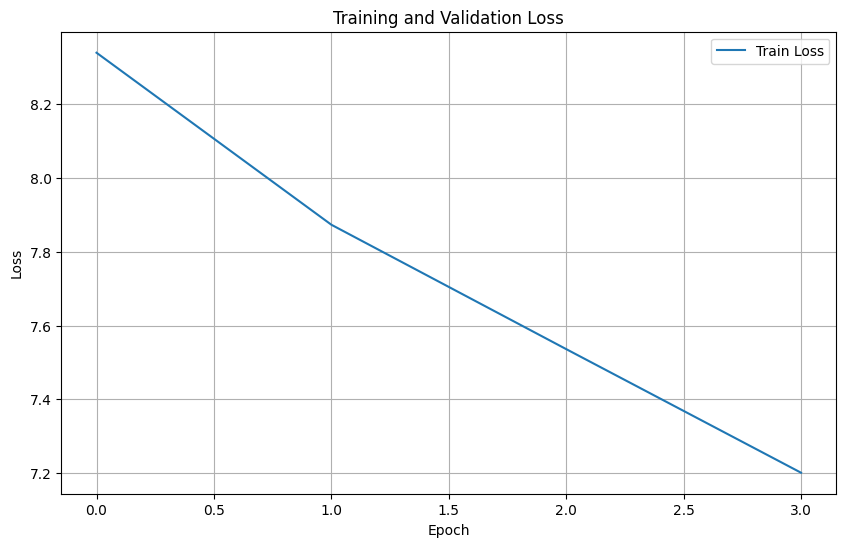

In [27]:
plt.figure(figsize=(10, 6))
plt.plot(train_losses, label='Train Loss')
if valid_losses: # Only plot if list is not empty
    plt.plot(valid_losses, label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

## Step 10: Inference (Generate Translations)

We will load our best model and generate translations for both the **Validation Set** (for weekly submissions) and the **Test Set** (for final submission).

In [28]:
def translate_sentence(sentence_tokens, en_vocab, tgt_vocab, model, device, max_length=MAX_LENGTH):
    """Translates a single tokenized source sentence."""

    model.eval()
    encoded_sentence = encode_and_pad(sentence_tokens, en_vocab, max_length)
    src_tensor = torch.LongTensor(encoded_sentence).unsqueeze(0).to(device)

    with torch.no_grad():
        hidden, cell = model.encoder(src_tensor)

    input_token = torch.LongTensor([SOS_token]).to(device)
    translated_indices = []

    for _ in range(max_length):
        with torch.no_grad():
            output, hidden, cell = model.decoder(input_token, hidden, cell)

        top1 = output.argmax(1)
        predicted_index = top1.item()

        if predicted_index == EOS_token:
            break

        translated_indices.append(predicted_index)
        input_token = top1

    translated_words = [tgt_vocab.index2word[idx] for idx in translated_indices]
    return " ".join(translated_words)

In [29]:
# Load the best model weights
print(f"Loading best model from {BEST_MODEL_NAME}")
try:
    model.load_state_dict(torch.load(BEST_MODEL_NAME))
except FileNotFoundError:
    print("WARNING: No saved model found. Using the model from the last epoch.")

# --- Generate translations for the VALIDATION set ---
val_translations = []
print(f"Generating {len(en_val_tokens)} translations for the VALIDATION set...")
for tokens in tqdm(en_val_tokens):
    translation = translate_sentence(tokens, en_vocab, tgt_vocab, model, device, MAX_LENGTH)
    val_translations.append(translation)

# --- Generate translations for the TEST set ---
test_translations = []
print(f"Generating {len(en_test_tokens)} translations for the TEST set...")
for tokens in tqdm(en_test_tokens):
    translation = translate_sentence(tokens, en_vocab, tgt_vocab, model, device, MAX_LENGTH)
    test_translations.append(translation)

print("Translation generation complete.")

Loading best model from best-model-bengali.pt
Generating 9836 translations for the VALIDATION set...


100%|██████████| 9836/9836 [02:40<00:00, 61.33it/s]


Generating 0 translations for the TEST set...


0it [00:00, ?it/s]

Translation generation complete.


In [33]:
# --- Check a few random examples ---
print("\n--- Example Test Translations ---")
#for i in random.sample(range(len(en_test_tokens)), 5):
    print(f"\nID: {id_test[i]}")
    print(f"  EN: {source_sentences_test[i]}")
    print(f"  TGT: {test_translations[i]}")


--- Example Test Translations ---


ValueError: Sample larger than population or is negative

## Step 11: Create Submission Files

We save the **Test Set** predictions to `answersB.csv`/`answersH.csv` (for the final combined file) and the **Validation Set** predictions to a separate file (for your weekly submissions).

In [34]:
# --- Save TEST SET Predictions (for final submission) ---
df_submission_test = pd.DataFrame()
df_submission_test["ID"] = id_test
df_submission_test["Translation"] = test_translations

# Save to CSV (e.g., answersB.csv or answersH.csv)
df_submission_test.to_csv(OUTPUT_CSV_NAME, index=False)
print(f"TEST set submission file saved as {OUTPUT_CSV_NAME}")
print(df_submission_test.head())

# --- Save VALIDATION SET Predictions (for weekly submissions) ---
val_output_name = f"val_{OUTPUT_CSV_NAME}" # e.g., val_answersB.csv
df_submission_val = pd.DataFrame()
df_submission_val["ID"] = id_val
df_submission_val["Translation"] = val_translations

df_submission_val.to_csv(val_output_name, index=False)
print(f"\nVALIDATION set submission file saved as {val_output_name}")
print(df_submission_val.head())

TEST set submission file saved as answersB.csv
Empty DataFrame
Columns: [ID, Translation]
Index: []

VALIDATION set submission file saved as val_answersB.csv
       ID                                        Translation
0  147532  অনেক থেকে থেকে এবং এবং এবং এবং এবং এবং এবং এবং...
1  147533         এখানে হল হল হল এবং এবং এবং এবং এবং এবং এবং
2  147534  এই এবং হল একটি এবং এবং এবং এবং এবং এবং এবং এবং...
3  147535                        এই সালে সালে সালে ছিল ছিল ৷
4  147536  একটি একটি একটি একটি একটি এবং এবং একটি একটি একট...


---
## 🚀 Next Steps: Run for Hindi

You have now successfully trained a model and generated `answersB.csv` (for Bengali).

**To get the Hindi translations, you must re-run this entire notebook:**
1.  **Restart the Runtime:** Go to `Runtime` > `Restart runtime` to clear all variables.
2.  **Change `LANG_PAIR_KEY`:** In **Step 1 (Cell 4)**, change the `LANG_PAIR_KEY` variable to:
    ```python
    LANG_PAIR_KEY = "English-Hindi"
    ```
3.  **Run All Cells:** Go to `Runtime` > `Run all`.

This will automatically set the `OUTPUT_CSV_NAME` to `answersH.csv` and `BEST_MODEL_NAME` to `best-model-hindi.pt`, training a new model on the Hindi data and saving the correct output file.

---

## Final Step: Combine and Format for Submission

Once you have **both** `answersB.csv` and `answersH.csv`, run the following cells (which are from your toy model) to combine them and create the final `answer.csv` and `submission.zip`.

In [ ]:
# Make sure both files exist before running this!
try:
    df_bengali = pd.read_csv("/content/answersB.csv") # Bengali
    df_hindi = pd.read_csv("/content/answersH.csv")  # Hindi

    print(f"Loaded {len(df_bengali)} Bengali translations.")
    print(f"Loaded {len(df_hindi)} Hindi translations.")

    # Concat
    df_combined = pd.concat([df_bengali, df_hindi])
    print(f"Combined total translations: {len(df_combined)}")

    # Save combined CSV
    df_combined.to_csv('answersBH.csv', index=False)

    # Display head
    df_combined.head()

except FileNotFoundError as e:
    print(f"ERROR: Could not find file. {e}")
    print("Please make sure you have run the notebook for BOTH language pairs and generated 'answersB.csv' and 'answersH.csv'.")

In [ ]:
# Format into the final tab-separated answer.csv
try:
    filtered_data = pd.read_csv("/content/answersBH.csv")

    # Fill any NaN translations with an empty string to avoid errors
    filtered_data['Translation'] = filtered_data['Translation'].fillna('')

    answer_file = "/content/answer.csv"
    with open(answer_file, "w") as f:
      f.writelines("ID\tTranslation\n")
      for i in range(filtered_data.shape[0]):
        # Ensure translation is a string and handle quotes inside it
        translation_text = str(filtered_data["Translation"][i]).replace('"', '""')
        f.writelines(f'{filtered_data["ID"][i]}\t"{translation_text}"\n')

    print(f"Successfully created final 'answer.csv'")
except NameError:
    print("ERROR: 'filtered_data' not defined. Did the cell above run correctly?")
except FileNotFoundError:
     print("ERROR: 'answersBH.csv' not found. Did the cell above run correctly?")

### Make a zip file of answer.csv and save it as submission.zip and submit it

In [ ]:
# This will create a submission.zip file in your Colab environment
# You can then download it from the file browser on the left.
!zip submission.zip /content/answer.csv